In [1]:
!pip install xgboost
!pip install lightgbm
!pip install shap
!pip install joblib

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [9]:
data = pd.read_csv("final_dataset.csv")

X = data.drop(["actual_delivery_time_min", "timestamp"], axis=1)

y = data["actual_delivery_time_min"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
def evaluate(model, name):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [13]:
lr = LinearRegression()

X_train_imputed = X_train.fillna(X_train.mean())
X_test_imputed = X_test.fillna(X_train.mean()) # Use X_train mean to avoid data leakage from test set


original_X_train = X_train
original_X_test = X_test
X_train = X_train_imputed
X_test = X_test_imputed

lr_result = evaluate(
    lr,
    "Linear Regression"
)

# Revert X_train and X_test to their original values after evaluation
X_train = original_X_train
X_test = original_X_test

In [14]:
rf = RandomForestRegressor(
    random_state=42
)

rf_result = evaluate(
    rf,
    "Random Forest"
)

In [15]:
xgb = XGBRegressor(

    random_state=42,

    n_estimators=200,

    learning_rate=0.05,

    max_depth=6
)

xgb_result = evaluate(
    xgb,
    "XGBoost"
)

In [16]:
lgbm = LGBMRegressor(

    random_state=42,

    n_estimators=200,

    learning_rate=0.05
)

lgbm_result = evaluate(
    lgbm,
    "LightGBM"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4124
[LightGBM] [Info] Number of data points in the train set: 56023, number of used features: 35
[LightGBM] [Info] Start training from score 34.668900


In [17]:
results = pd.DataFrame([

    lr_result,

    rf_result,

    xgb_result,

    lgbm_result

])

results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
2,XGBoost,3.773023,15.623535,0.988491
1,Random Forest,4.350379,28.920653,0.960565
3,LightGBM,5.009990,52.659575,0.869258
0,Linear Regression,6.291925,67.480405,0.785308


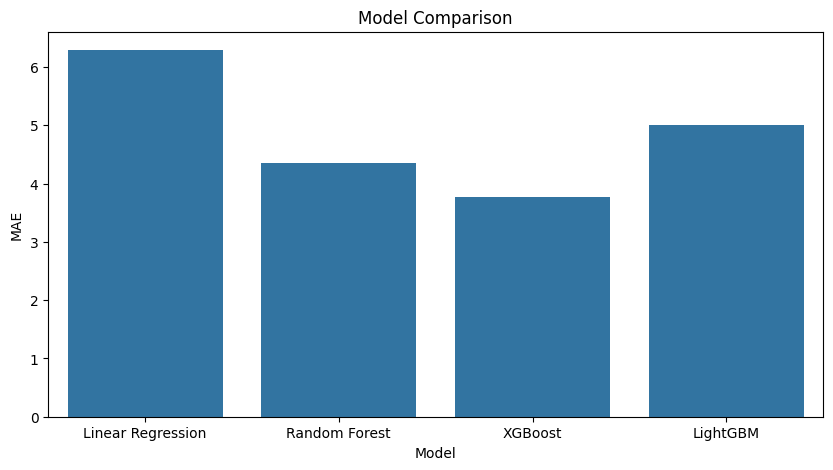

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison")

plt.show()

In [19]:
best_model_name = results.sort_values(
    "MAE"
).iloc[0]["Model"]

print(best_model_name)

XGBoost


In [20]:
params = {

    "n_estimators":[100,200,300],

    "max_depth":[4,6,8],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.8,1.0]
}

In [21]:
grid = GridSearchCV(

    XGBRegressor(random_state=42),

    params,

    cv=5,

    scoring="neg_mean_absolute_error",

    n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_absolute_error')

In [22]:
best_model = grid.best_estimator_

In [23]:
scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5,

    scoring="neg_mean_absolute_error"
)

print(scores)

print(np.mean(scores))

[-3.79857472 -4.36678374 -4.60450316 -4.2094413  -4.06241437]
-4.208343460956626


In [24]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

,Feature,Importance
0,drop_lat,0.496543
4,promised_eta,0.215027
5,order_status,0.132682
28,restaurant_customer_distance,0.067366
22,month,0.015941
30,rider_experience,0.009280
32,vehicle_speed,0.009023
7,lat,0.006950
11,prep_capacity,0.004207
9,cuisine,0.004155


In [30]:
joblib.dump(
    best_model,
    "model.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "features.pkl"
)

['features.pkl']

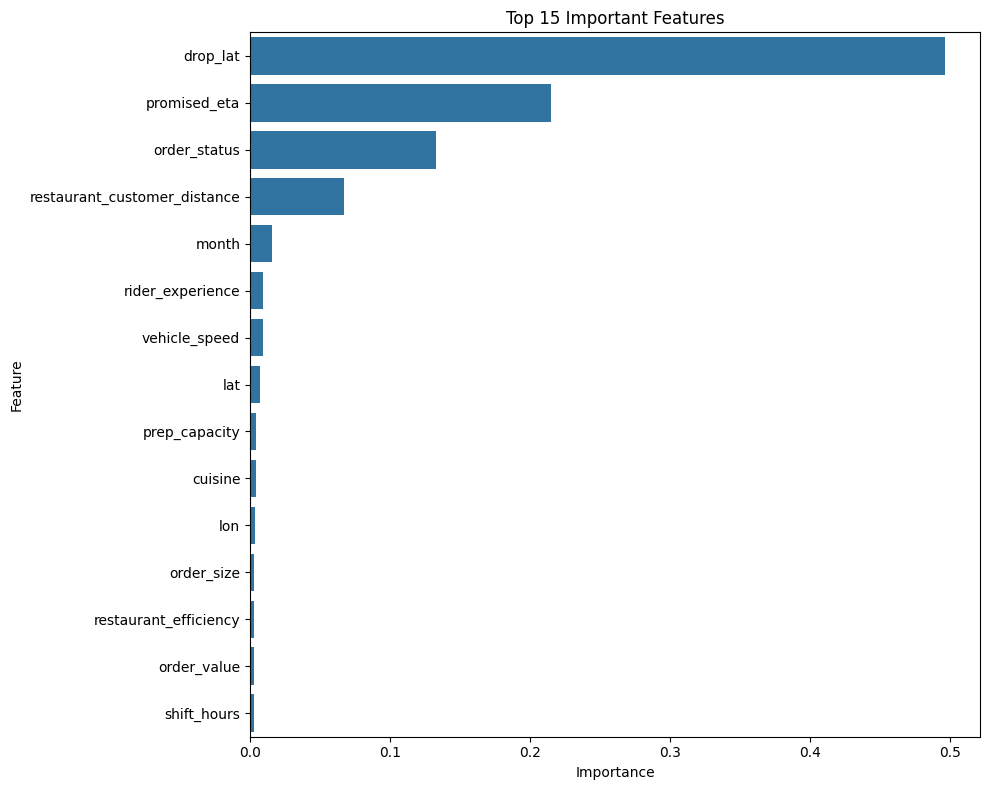

In [47]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.tight_layout()

# Save BEFORE show
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
import json

metrics = {
    "Model": best_model.__class__.__name__,
    "MAE": float(mean_absolute_error(y_test, best_model.predict(X_test))),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, best_model.predict(X_test)))),
    "R2": float(r2_score(y_test, best_model.predict(X_test)))
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [34]:
import shap

explainer = shap.Explainer(best_model)

shap_values = explainer(X_test)

In [39]:
joblib.dump(
    shap_values,
    "shap_values.pkl"
)

['shap_values.pkl']

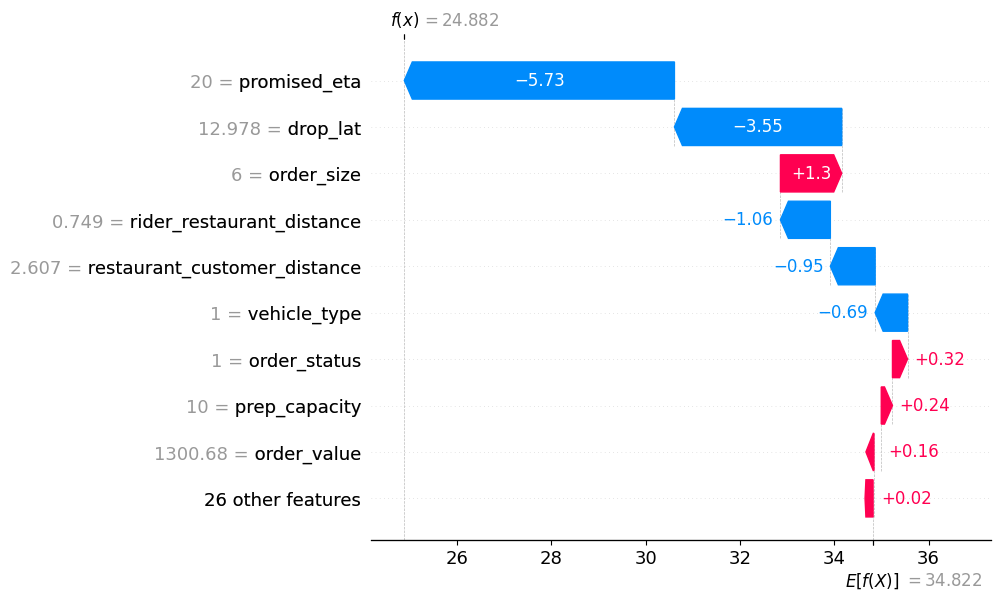

In [35]:
shap.plots.waterfall(shap_values[0])

In [42]:
plt.savefig(
    "shap_waterfall.png"
)

<Figure size 640x480 with 0 Axes>

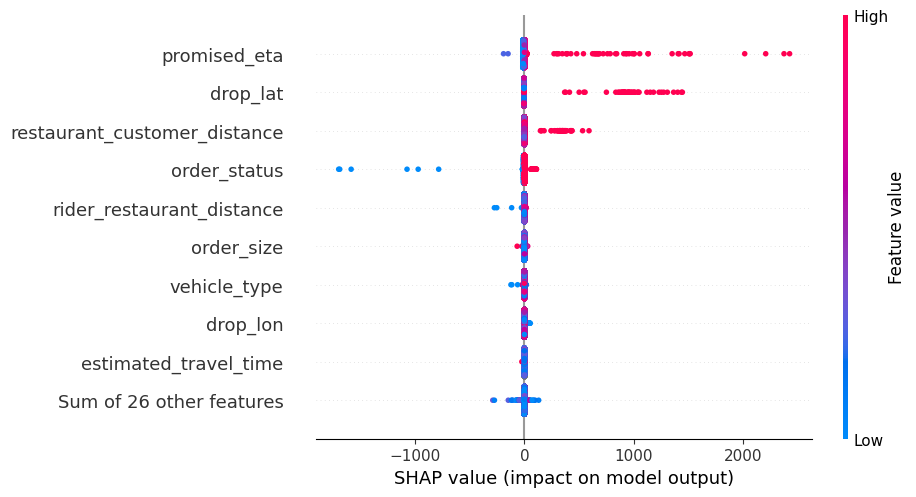

In [36]:
shap.plots.beeswarm(shap_values)

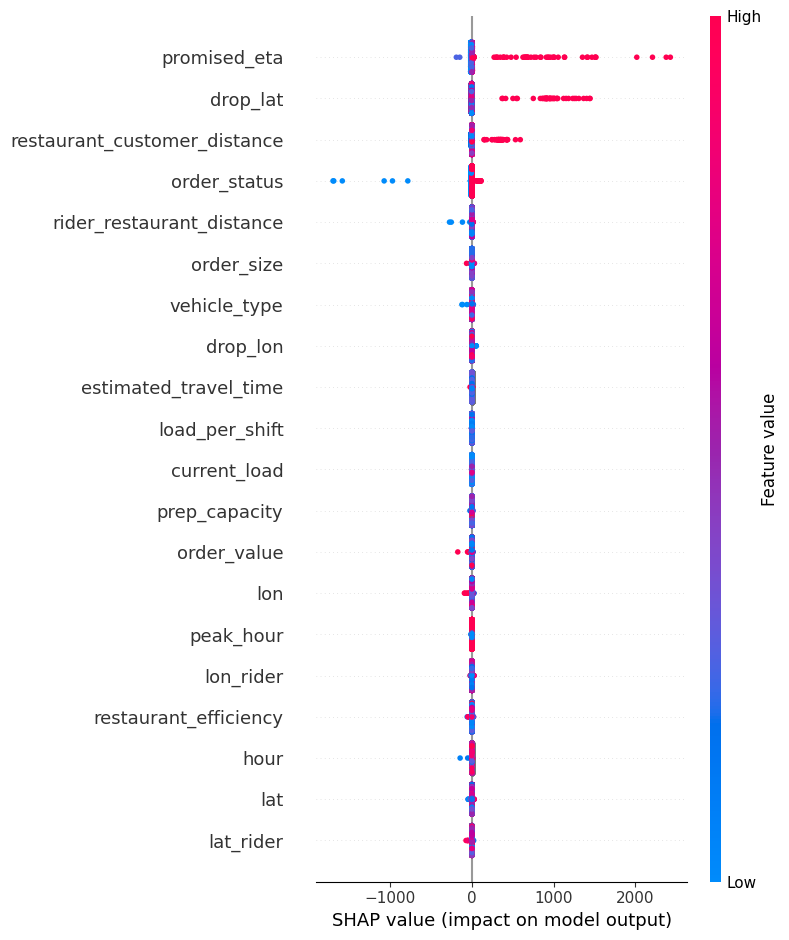

In [38]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig("shap_summary.png")

In [43]:
best_params = grid.best_params_

best_params

{'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}

In [44]:
joblib.dump(
    best_params,
    "best_params.pkl"
)

['best_params.pkl']

In [48]:
import json
import numpy as np

model_info = {
    "model": "XGBoost",
    "best_parameters": grid.best_params_,
    "cross_validation_mae": float(abs(np.mean(scores))),
    "cross_validation_scores": scores.tolist()
}

with open("model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("model_info.json saved successfully!")

model_info.json saved successfully!
